In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.spatial import cKDTree
import xarray as xr
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

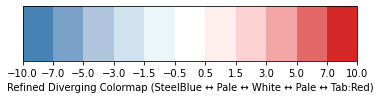

In [ ]:
# Customized colormap for refined diverging color scheme
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm

# Define the levels (edges between bins)
levels1 = [-10,-7,-5,-3,-1.5,-0.5,0.5,1.5,3,5,7,10]

# Custom diverging colormap with lighter shades near zero
brcmap = LinearSegmentedColormap.from_list(
    'custom_diverging',
    [
        (0.0, '#4682B4'),   # Steel blue (deep negative)
        (0.2, '#B0C4DE'),   # Light steel blue
        (0.35, '#E0F2F7'),  # Very pale blue (near -0.1)
        (0.5, 'white'),     # Center at zero
        (0.65, '#FFE5E5'),  # Very pale red (near +0.1)
        (0.8, '#F4A6A6'),   # Light red
        (1.0, '#d62728')    # Tab:red (deep positive)
    ],
    N=256
)

# Use BoundaryNorm to discretize color levels
brnorm1 = BoundaryNorm(levels1, ncolors=brcmap.N, clip=True)

# Plot colorbar
fig, ax = plt.subplots(figsize=(6, 1))
cb = plt.colorbar(
    plt.cm.ScalarMappable(norm=brnorm1, cmap=brcmap),
    cax=ax, orientation='horizontal', ticks=levels1
)
cb.set_label("Refined Diverging Colormap (SteelBlue ↔ Pale ↔ White ↔ Pale ↔ Tab:Red)")
plt.show()


In [ ]:
# Taylor diagram functions
def _safe_flatten_pair(ref, other, weights=None):
    """Return flattened paired arrays after masking NaNs and optional weights."""
    ref = np.asarray(ref)
    other = np.asarray(other)
    if ref.shape != other.shape:
        raise ValueError("ref and other must have same shape")
    mask = np.isfinite(ref) & np.isfinite(other)
    r = ref[mask].ravel()
    o = other[mask].ravel()
    if weights is not None:
        w = np.asarray(weights)[mask].ravel()
        w = w / np.sum(w)
    else:
        w = None
    return r, o, w

def weighted_mean_std(a, w=None):
    a = np.asarray(a)
    if w is None:
        m = a.mean()
        s = a.std(ddof=0)
    else:
        w = np.asarray(w)
        m = np.sum(w * a)
        var = np.sum(w * (a - m)**2)
        s = np.sqrt(var)
    return m, s

def weighted_cov_corr(a, b, w=None):
    a = np.asarray(a); b = np.asarray(b)
    if w is None:
        a_m = a.mean(); b_m = b.mean()
        cov = np.mean((a - a_m)*(b - b_m))
        denom = a.std(ddof=0) * b.std(ddof=0)
    else:
        w = np.asarray(w)
        a_m = np.sum(w * a); b_m = np.sum(w * b)
        cov = np.sum(w * (a - a_m) * (b - b_m))
        denom = np.sqrt(np.sum(w*(a-a_m)**2) * np.sum(w*(b-b_m)**2))
    corr = cov / denom if denom != 0 else np.nan
    return cov, corr

def taylor_stats(ref, model, weights=None, remove_mean=True):
    r, m, w = _safe_flatten_pair(ref, model, weights)
    if remove_mean:
        if w is None:
            r = r - r.mean()
            m = m - m.mean()
        else:
            rm = np.sum(w * r); mm = np.sum(w * m)
            r = r - rm
            m = m - mm
    mean_r, std_r = weighted_mean_std(r, w)
    mean_m, std_m = weighted_mean_std(m, w)
    cov, corr = weighted_cov_corr(r, m, w)
    # centered RMS
    crms = np.sqrt(std_r**2 + std_m**2 - 2*std_r*std_m*corr)
    return dict(std_ref=std_r, std_model=std_m, corr=corr, crms=crms)

def prepare_fields(ref, model, lat=None):
    # mask invalids
    mask = np.isfinite(ref) & np.isfinite(model)
    r = ref[mask].ravel()
    m = model[mask].ravel()
    
    # optional: area weighting
    if lat is not None:
        # broadcast lat to 2D
        w = np.cos(np.deg2rad(lat))[:, None] * np.ones(ref.shape[1])
        w = w[mask].ravel()
        w /= w.sum()  # normalize weights
    else:
        w = None
    return r, m, w

def plot_taylor_diagram(ref, models, weights=None, model_labels=None, markers=None,
                        normalize=False, fig=None, ax=None, ct=None, legend=True,
                        std_ticks=None, corr_ticks=None, title=None, draw_lines=True):
    """
    ref: 2D or 1D array (reference)
    models: list of arrays to compare (same shape as ref)
    weights: optional weights (same shape) for area-weighting
    normalize: if True, normalize std by reference std (so ref std = 1)
    """

    # compute stats
    stats = taylor_stats(ref, models, weights, remove_mean=True)
    std_ref = stats["std_ref"]
    std_m = stats["std_model"]
    rho = stats["corr"]

    if normalize:
        std_ref_plot = 1.0
        std_model_plot = std_m / std_ref
    else:
        std_ref_plot = std_ref
        std_model_plot = std_m

    # build plot area (Cartesian) for easier drawing of RMS circles
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(12,12))
    ax.set_aspect('equal')

    # correlation ticks and angle mapping
    if corr_ticks is None:
        corr_ticks = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 1.0])
    angles = np.arccos(corr_ticks)  # angle = arccos(rho)

    # prepare radial ticks    
    max_std = 1.75
    if std_ticks is None:
        std_ticks = np.linspace(0, np.ceil(max_std*1.2), 6)[1:]  # skip 0

    if markers is None:
        markers = ['o'] * len(models)
    
    # plot model point
    label=model_labels[0]
    theta = np.arccos(np.clip(rho, -1, 1))
    x = std_model_plot * np.cos(theta)
    y = std_model_plot * np.sin(theta)
    mec='k'
    ms=9
    if ct==12:
        ms=12
        mec='r'
    ax.plot(x, y, linestyle='None', marker=markers, ms=ms, label=f"{label}",color=mec, markeredgewidth=0.15)
    if legend:
        leg=ax.legend(loc='upper right', bbox_to_anchor=(1.1, -0.05),ncol=3,columnspacing=0.2,frameon=False)
    # for handle in leg.legendHandles:
    #     handle.set_color('black')
        
    if not draw_lines:
        return fig, ax
    # plot reference point
    ax.text(0.95,0.01, 'Ref', fontsize=10)

    # draw std dev radial grid lines (concentric circles centered at origin)
    grid_r = std_ticks
    for r in grid_r:
        if r == 0.5 or r == 1.0:
            circle = plt.Circle((0, 0), r, transform=ax.transData, fill=False, linestyle=':', linewidth=0.8)
            ax.add_artist(circle)
        elif r == 1.75:
            circle = plt.Circle((0, 0), r, transform=ax.transData, fill=False, linestyle='-', linewidth=1, color='k')
            ax.add_artist(circle)
        #ax.text(r, 0, f" {r:.2f}", va='bottom', fontsize=8)

    # draw correlation angle lines and labels
    for rho, ang in zip(corr_ticks, angles):
        x = np.array([0, 1.75*np.cos(ang)])
        y = np.array([0, 1.75*np.sin(ang)])
        x1 = np.array([1.75*np.cos(ang), 1.763*np.cos(ang)])
        y1 = np.array([1.75*np.sin(ang), 1.763*np.sin(ang)])
        if rho==0.5 or rho==0.8 or rho==0.97:
            ax.plot(x, y, color='0.7', linewidth=0.6)
        ax.plot(x1, y1, color='0.0', linewidth=0.6)
        lx = 1.81*np.cos(ang)
        ly = 1.81*np.sin(ang)
        if rho == 0.97:
            ax.text(lx+0.01, ly+0.01, f"{rho:.2f}", ha='center', va='center', fontsize=11)
        else:
            ax.text(lx, ly, f"{rho:.1f}", ha='center', va='center', fontsize=11)

    # draw centered-RMS contours (circles centered at ref point)
    # xs = np.linspace(-max_std*0.1, max_std*1.4, 400)
    # ys = np.linspace(-max_std*0.1, max_std*0.6, 400)
    #X, Y = np.meshgrid(xs, ys)

    #draw a subset of crms contours
    crms_levels = [0.25, 0.5, 0.75, 1.0]
    for level in crms_levels:
        # for each phi, compute std and corr that satisfy the RMS equation
        std = np.linspace(0, 1.75, 400)
        std = np.delete(std, 0)
        x_vals = []
        y_vals = []
        for s in std:
            # solve for corr: crms^2 = std_ref_plot^2 + s^2 - 2*std_ref_plot*s*corr
            corr = (std_ref_plot**2 + s**2 - level**2) / (2*std_ref_plot*s) if s > 0 else 1.0
            if -1 <= corr <= 1:
                theta = np.arccos(corr)
                x_vals.append(s * np.cos(theta))
                y_vals.append(s * np.sin(theta))
        ax.plot(x_vals, y_vals, color='k', linestyle='dashdot', linewidth=0.6)

    if 'top' in ax.spines:
        ax.spines['top'].set_visible(False)
    if 'right' in ax.spines:
        ax.spines['right'].set_visible(False)

    ax.set_xlim(-0.00, 1.75)
    ax.set_ylim(-0.00, 1.75)
    ax.set_xticks(np.arange(0,2,0.25))
    ax.set_yticks(np.arange(0,2,0.25))
    ax.set_xlabel(' ')
    ax.set_ylabel('Standard deviation (Normalized)',fontsize=12)
    ax.text(1.25, 1.25, 'Correlation', rotation=-45, fontsize=12)
    # ax.set_title('HR: red', c='tab:red', pad=20, loc='center')
    # ax.set_title('LR: blue', c='tab:blue', pad=20, loc='right')
    ax.set_title(title or 'Taylor diagram', pad=30, loc='left', fontsize=16)
    #plt.tight_layout()
    return fig, ax

In [ ]:
# Load IB data
dfib = pd.read_csv("../IB_track_file/IBTrACS_TC_Size.csv",keep_default_na=False)

In [ ]:
# Load SyCLoPS data
files ={
    'mris': '../final_track_file/mris_SyCLoPS.csv',
    'mrih': '../final_track_file/mrih_SyCLoPS.csv',
    'ipslvhr': '../final_track_file/ipslvhr_SyCLoPS.csv',
    'ipslhr': '../final_track_file/ipslhr_SyCLoPS.csv',
    'echrm1': '../final_track_file/echrm1_SyCLoPS.csv',
    'eclrm1': '../final_track_file/eclrm1_SyCLoPS.csv',
    'era5deg1': '../final_track_file/era5deg1_SyCLoPS.csv',
    'era5': '../final_track_file/era5_SyCLoPS.csv',
    'hadgem': '../final_track_file/hadgem_SyCLoPS.csv',
    'cnrm': '../final_track_file/cnrm_SyCLoPS.csv',
    'hadgem-coup': '../final_track_file/hadgem-coup_SyCLoPS.csv',
    'cnrm-coup': '../final_track_file/cnrm-coup_SyCLoPS.csv',
    'echrm1-coup': '../final_track_file/echrm1-coup_SyCLoPS.csv',
    'ecearth3p': '../final_track_file/ecearth3p_SyCLoPS.csv'
}

dfpike = {}
for name, path in files.items():
    df = pd.read_csv(path,keep_default_na=False)
    dfpike[name] = df

In [ ]:
# Load ZU data
ZU_files = {
    'hadgemo': '../final_track_file/hadgem_ZU.csv',
    'cnrmo': '../final_track_file/cnrm_ZU.csv',
    'hadgem-coupo': '../final_track_file/hadgem-coup_ZU.csv',
    'cnrm-coupo': '../final_track_file/cnrm-coup_ZU.csv',
    'ecearth3po': '../final_track_file/ecearth3p_ZU.csv',
    'echrm1-coupo': '../final_track_file/echrm1-coup_ZU.csv',
    'era5o': '../final_track_file/era5_ZU.csv',
    'era5deg1o': '../final_track_file/era5deg1_ZU.csv',
    'mriso': '../final_track_file/mris_ZU.csv',
    'mriho': '../final_track_file/mrih_ZU.csv',
    'ipslvhro': '../final_track_file/ipslvhr_ZU.csv',
    'ipslhro': '../final_track_file/ipslhr_ZU.csv',
    'echrm1o': '../final_track_file/echrm1_ZU.csv',
    'eclrm1o': '../final_track_file/eclrm1_ZU.csv'
}

# Load and clean CSVs
dfo_tc = {}
for name, path in ZU_files.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df = df.rename(columns={"lon": "LON", "lat": "LAT", "track_id": "TID"})
    if name =='era5o':
        df=df[df.year.between(1988, 2014)]
    dfo_tc[name] = df


In [8]:
# Figure 4 preparation

coor=[]
lon0=np.arange(0,360,4.0)
lat0=np.arange(-90,90,4.0)

for x in lat0:
    for y in lon0:
        coor.append((x,y))
coor=np.array(coor)

T = cKDTree(coor)

dft1=dfib
lon1=dft1.LON
lat1=dft1.LAT
coor1=list(zip(lat1,lon1))
coor_count=np.zeros(len(coor))
for i in range(len(coor1)):
    dist,ind = T.query(coor1[i], k=1)  
    coor_count[ind]+=1
datacount_ib= coor_count.reshape([45,90])

for key, dft in dfpike.items():
    lon1 = dft.LON.values
    lat1 = dft.LAT.values
    coor1 = list(zip(lat1, lon1))
    coor_count = np.zeros(len(coor))
    for i in range(len(coor1)):
        dist, ind = T.query(coor1[i], k=1)
        coor_count[ind] += 1
    globals()[f"datacount_{key}"] = coor_count.reshape([45, 90])
    

# ensemble mean
all_model_keys = [
    'mris', 'mrih', 'ipslvhr', 'ipslhr', 'echrm1', 'eclrm1', 'hadgem', 'cnrm',
    'hadgem-coup', 'cnrm-coup', 'echrm1-coup', 'ecearth3p'
]
all_model_counts = [globals()[f"datacount_{k}"] for k in all_model_keys]
all_model_mean = np.mean(all_model_counts, axis=0)
globals()["datacount_allmean"] = all_model_mean

    
for key, dft in dfo_tc.items():
    # if key=='era5o':
    #     dft=dft[dft.FA==0]
    lon1 = dft.LON.values
    lat1 = dft.LAT.values
    coor1 = list(zip(lat1, lon1))
    coor_count = np.zeros(len(coor))
    for i in range(len(coor1)):
        dist, ind = T.query(coor1[i], k=1)
        coor_count[ind] += 1
    globals()[f"datacount_{key}"] = coor_count.reshape([45, 90])

old_model_keys = [
    'mriso', 'mriho', 'ipslvhro', 'ipslhro', 'echrm1o', 'eclrm1o', 'hadgemo', 'cnrmo',
    'hadgem-coupo', 'cnrm-coupo', 'echrm1-coupo', 'ecearth3po'
]

old_model_counts = [globals()[f"datacount_{k}"] for k in old_model_keys]
old_model_mean = np.mean(old_model_counts, axis=0)
globals()["datacount_allmeano"] = old_model_mean


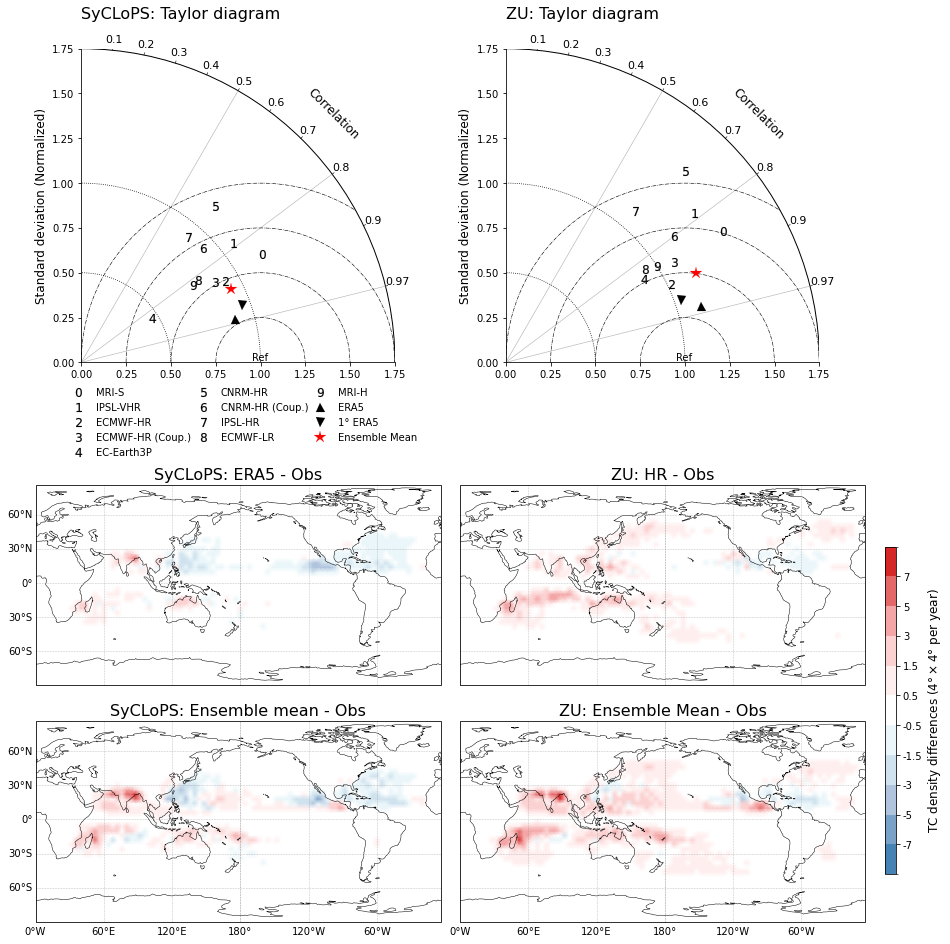

In [ ]:
fig = plt.figure(figsize=(12,13),layout='constrained')
gs = fig.add_gridspec(3,2,height_ratios=[1.4,1,1],width_ratios=[1,1])

ref_map = datacount_ib
modles_name = ['mris','ipslvhr','echrm1','echrm1-coup','ecearth3p','cnrm','cnrm-coup','ipslhr','eclrm1','mrih','era5','era5deg1','allmean']
modleso_name= ['mriso','ipslvhro','echrm1o','echrm1-coupo','ecearth3po','cnrmo','cnrm-coupo','ipslhro','eclrm1o','mriho','era5o','era5deg1o','allmeano']
model_list = ['MRI-S','IPSL-VHR','ECMWF-HR','ECMWF-HR (Coup.)','EC-Earth3P','CNRM-HR','CNRM-HR (Coup.)','IPSL-HR','ECMWF-LR','MRI-H','ERA5','1° ERA5','Ensemble Mean']
labels = model_list

markers = ["$0$", "$1$", "$2$", "$3$", "$4$", "$5$", "$6$", "$7$", "$8$", "$9$", "^", "v", "*"]

ax = fig.add_subplot(gs[0, 0])
for i, name in enumerate(modles_name):
    model_map = globals()[f"datacount_{name}"]
    r, m, w = prepare_fields(ref_map, model_map, lat=lat0)
    if i == 0 :
        plot_taylor_diagram(r, m, w, model_labels=[model_list[i]], normalize=True, fig=fig, ax=ax, markers=markers[i],ct=i,
                        corr_ticks=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.97], std_ticks=np.arange(0,2.0,0.25),title='SyCLoPS: Taylor diagram')
    else:
        plot_taylor_diagram(r, m, w, model_labels=[model_list[i]], normalize=True, fig=fig, ax=ax, draw_lines=False, markers=markers[i],ct=i,
                        corr_ticks=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.97], std_ticks=np.arange(0,2.0,0.25))
        
ax = fig.add_subplot(gs[1,0],projection=ccrs.PlateCarree(central_longitude=180))
hr_ref_diff=globals()['datacount_era5'] - globals()['datacount_ib']
pt1=ax.pcolormesh(lon0, lat0, hr_ref_diff/27,
                transform=ccrs.PlateCarree(),
                cmap=brcmap,norm=brnorm1,shading='gouraud')
ax.coastlines('110m', linewidth=0.5)
#ax.set_extent([0,359,-65,65])
plt.title('SyCLoPS: ERA5 - Obs',fontsize=16)
gl = ax.gridlines(draw_labels=True,xformatter=LongitudeFormatter(zero_direction_label=True),linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False;gl.right_labels = False; gl.left_labels = True; gl.bottom_labels = False

ax = fig.add_subplot(gs[2,0],projection=ccrs.PlateCarree(central_longitude=180))
hr_lr_diff=globals()['datacount_allmean'] - globals()['datacount_ib']
pt1=ax.pcolormesh(lon0, lat0, hr_lr_diff/27,
                transform=ccrs.PlateCarree(),
                cmap=brcmap,norm=brnorm1,shading='gouraud')
ax.coastlines('110m', linewidth=0.5)
#ax.set_extent([0,359,-65,65])
plt.title('SyCLoPS: Ensemble mean - Obs',fontsize=16)
gl = ax.gridlines(draw_labels=True,xformatter=LongitudeFormatter(zero_direction_label=True),linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False;gl.right_labels = False; gl.left_labels = True; gl.bottom_labels = True

ax = fig.add_subplot(gs[0,1])
for i, name in enumerate(modleso_name):
    model_map = globals()[f"datacount_{name}"]
    r, m, w = prepare_fields(ref_map, model_map, lat=lat0)
    if i == 0 :
        plot_taylor_diagram(r, m, w, model_labels=[model_list[i]], normalize=True, fig=fig, ax=ax, markers=markers[i],ct=i,
                        corr_ticks=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.97], std_ticks=np.arange(0,2.0,0.25),title='ZU: Taylor diagram',legend=False)
    else:
        plot_taylor_diagram(r, m, w, model_labels=[model_list[i]], normalize=True, fig=fig, ax=ax, draw_lines=False, markers=markers[i],ct=i,
                        corr_ticks=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.97], std_ticks=np.arange(0,2.0,0.25), legend=False)
        
ax = fig.add_subplot(gs[1,1],projection=ccrs.PlateCarree(central_longitude=180))
hr_ref_diff=globals()['datacount_era5o'] - globals()['datacount_ib']
pt1=ax.pcolormesh(lon0, lat0, hr_ref_diff/27,
                transform=ccrs.PlateCarree(),
                cmap=brcmap,norm=brnorm1,shading='gouraud')
ax.coastlines('110m', linewidth=0.5)
#ax.set_extent([0,359,-65,65])
plt.title('ZU: HR - Obs',fontsize=16)
gl = ax.gridlines(draw_labels=True,xformatter=LongitudeFormatter(zero_direction_label=True),linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False;gl.right_labels = False; gl.left_labels = False; gl.bottom_labels = False
cax = fig.add_axes([1.02, 0.07, 0.012, 0.35])
cbar=plt.colorbar(pt1,cax=cax,label=r'TC density differences (4$\degree \times 4\degree$ per year)',orientation='vertical')
cbar.ax.yaxis.label.set_size(12)
cbar.set_ticks([-7,-5,-3,-1.5, -0.5, 0.5, 1.5, 3, 5, 7])
cbar.set_ticklabels(['-7', '-5', '-3', '-1.5', '-0.5', '0.5', '1.5', '3', '5', '7'])

ax = fig.add_subplot(gs[2,1],projection=ccrs.PlateCarree(central_longitude=180))
hr_lr_diff=globals()['datacount_allmeano'] - globals()['datacount_ib']
pt1=ax.pcolormesh(lon0, lat0, hr_lr_diff/27,
                transform=ccrs.PlateCarree(),
                cmap=brcmap,norm=brnorm1,shading='gouraud')
ax.coastlines('110m', linewidth=0.5)
#ax.set_extent([0,359,-65,65])
#cbar=plt.colorbar(pt1,label='TC number difference',orientation='vertical',shrink=0.9,aspect=30)
cbar.set_ticks([-7,-5,-3,-1.5, -0.5, 0.5, 1.5, 3, 5, 7])
cbar.set_ticklabels(['-7', '-5', '-3', '-1.5', '-0.5', '0.5', '1.5', '3', '5', '7'])

plt.title('ZU: Ensemble Mean - Obs',fontsize=16)
gl = ax.gridlines(draw_labels=True,xformatter=LongitudeFormatter(zero_direction_label=True),linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False;gl.right_labels = False; gl.left_labels = False; gl.bottom_labels = True

fig.savefig('../figures/figure4.jpg', dpi=500, bbox_inches='tight')